# Linear regression model for house price prediction


### Imports

In [1]:
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

#### Reading CSV

In [2]:
data = pd.read_csv("data.csv")

In [3]:
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
data.drop(columns = ['date','street','statezip','country'], inplace = True)

In [5]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond


In [6]:
Y = data['price']
Y.head()

0     313000.0
1    2384000.0
2     342000.0
3     420000.0
4     550000.0
Name: price, dtype: float64

In [7]:
X = data.drop(columns = 'price')

In [8]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond


In [9]:
encoder = LabelEncoder()

X['city_encoded'] = encoder.fit_transform(X['city']) + 1

In [10]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,city_encoded
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,37
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,36
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,19
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,4
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,32


In [11]:
X.drop(columns = 'city', inplace = True)

In [12]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city_encoded
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,37
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,36
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,19
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,4
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,32


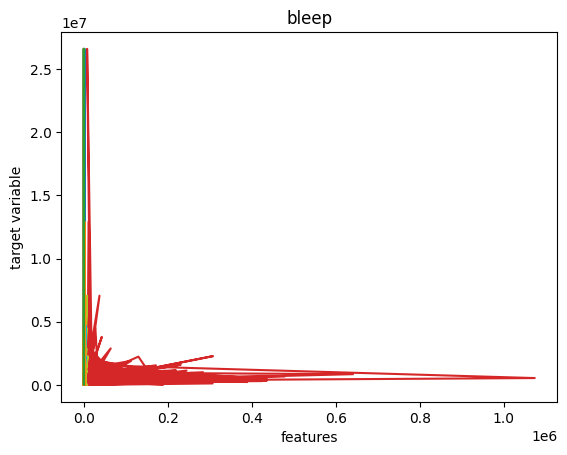

In [13]:
plt.plot(X, Y)

plt.title('bleep')
plt.xlabel('features')
plt.ylabel('target variable')

plt.show()

In [14]:
X['house_age'] = 2026 - X['yr_built']

In [15]:
X.drop(columns = 'yr_built', inplace = True)
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_renovated,city_encoded,house_age
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,2005,37,71
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,0,36,105
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,0,19,60
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,0,4,63
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1992,32,50


In [16]:
X['renovation_age'] = np.where(X['yr_renovated'] > 0, 2026 - X['yr_renovated'], 0 )

In [17]:
X.drop(columns = 'yr_renovated', inplace = True)
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,city_encoded,house_age,renovation_age
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,37,71,21
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,36,105,0
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,19,60,0
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,4,63,0
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,32,50,34


In [19]:
X = pd.get_dummies(X, columns= ['city_encoded'], drop_first = True)

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [23]:
X

array([[-0.44112227, -0.84320364, -0.82997105, ..., -0.0796514 ,
        -0.16012815, -0.02950122],
       [ 1.75970468,  0.43280154,  1.56852826, ..., -0.0796514 ,
        -0.16012815, -0.02950122],
       [-0.44112227, -0.20520105, -0.21736733, ..., -0.0796514 ,
        -0.16012815, -0.02950122],
       ...,
       [-0.44112227,  0.43280154,  0.90400897, ..., -0.0796514 ,
        -0.16012815, -0.02950122],
       [ 0.6592912 , -0.20520105, -0.05123751, ..., -0.0796514 ,
        -0.16012815, -0.02950122],
       [-0.44112227,  0.43280154, -0.67422434, ..., -0.0796514 ,
        -0.16012815, -0.02950122]], shape=(4600, 55))

In [ ]:
X = pd.DataFrame(X, columns=X.columns)

print(X.head())

### Model

In [25]:
model = linear_model.LinearRegression()

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [27]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = model.predict(X_test)

#### model analysis

In [ ]:
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_test, Y_pred))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_test, Y_pred))